# Knowledge Base Q&A System — Prototype

A **Corrective RAG (CRAG)** pipeline built with **LangChain** and **LangGraph**.

## Architecture
```
START → retrieve → grade_documents ─┬─► generate → END
                        ▲           │
                        │           └─► transform_query ─┘
                        └────────────────────────────────
```

| Node | Role |
|---|---|
| `retrieve` | Fetch top-k chunks from FAISS vector store |
| `grade_documents` | LLM judges each chunk for relevance; filters noise |
| `generate` | Produce the final answer from relevant chunks |
| `transform_query` | Rewrite the question when no relevant chunks found |


## 1. Setup

In [2]:
import os
from pathlib import Path
from typing import TypedDict, Literal

from dotenv import load_dotenv
load_dotenv(Path('../.env'))

from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

print('Setup complete.')


Setup complete.


In [3]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
print('LLM: gpt-4o-mini | Embeddings: text-embedding-3-small')


LLM: gpt-4o-mini | Embeddings: text-embedding-3-small


## 2. Knowledge Base

Sample documents about a fictional product **"TechBase Pro"**.

In [4]:
sample_documents = [
    Document(
        page_content=(
            'TechBase Pro is an enterprise knowledge management platform powered by AI. '
            'Key features: semantic search across all company documents, '
            'automatic document summarization, real-time collaboration, version control, '
            'and integrations with Slack, Jira, and Confluence. '
            'Supported file types: PDF, Word, Excel, PowerPoint, and Markdown. '
            'Uses vector embeddings for natural language queries over your documents.'
        ),
        metadata={'source': 'product_overview', 'category': 'product'},
    ),
    Document(
        page_content=(
            'TechBase Pro pricing plans: '
            'Starter (Free) — up to 5 users, 10 GB storage, 1,000 queries/month. '
            'Professional ($49/user/month) — unlimited users, 100 GB storage, unlimited queries, '
            'SSO, priority support, advanced analytics. '
            'Enterprise (custom pricing) — unlimited storage, dedicated infrastructure, '
            'SLA guarantees, custom integrations, on-premise deployment, '
            '24/7 dedicated support with 1-hour response SLA.'
        ),
        metadata={'source': 'pricing', 'category': 'pricing'},
    ),
    Document(
        page_content=(
            'Security & Compliance: TechBase Pro is SOC 2 Type II certified and GDPR compliant. '
            'Data is encrypted at rest (AES-256) and in transit (TLS 1.3). '
            'SSO via SAML 2.0 and OIDC. Role-based access control (RBAC) for fine-grained permissions. '
            'Data residency options for EU and US regions. '
            'Annual third-party penetration testing. '
            'HIPAA BAA available for Enterprise customers.'
        ),
        metadata={'source': 'security', 'category': 'security'},
    ),
    Document(
        page_content=(
            'Integration Guide: TechBase Pro exposes a RESTful API with OAuth 2.0 auth. '
            'SDKs available for Python, JavaScript, Go, and Java. '
            'Webhook support for real-time event notifications. '
            'Native integrations: Slack, Microsoft Teams, Google Workspace (Drive, Docs), '
            'Jira, Confluence, GitHub, and Zendesk. '
            'API rate limits: 1,000 req/min (Professional), 10,000 req/min (Enterprise).'
        ),
        metadata={'source': 'integrations', 'category': 'technical'},
    ),
    Document(
        page_content=(
            'Support Policy: Professional plan — email and chat support, 4-hour response '
            'during business hours (9 am–6 pm EST, Mon–Fri). '
            'Enterprise plan — 24/7 phone, email, and chat support, 1-hour SLA for critical issues. '
            'All customers: self-service knowledge base, video tutorials, community forum. '
            'Dedicated Customer Success Managers assigned to Enterprise accounts. '
            'Onboarding and training sessions available for all paid plans.'
        ),
        metadata={'source': 'support', 'category': 'support'},
    ),
    Document(
        page_content=(
            'Getting Started: Create an account at app.techbasepro.ai. '
            'Connect data sources via the integrations panel. '
            'Upload documents through the web UI, REST API, or desktop sync client. '
            'Configure RBAC and invite team members. '
            'AI indexing processes new documents within 5 minutes. '
            'Admin dashboard provides usage analytics, cost tracking, and audit logs. '
            'The system suggests related documents and prior answers to reduce duplicate queries.'
        ),
        metadata={'source': 'getting_started', 'category': 'product'},
    ),
]

print(f'Loaded {len(sample_documents)} documents.')


Loaded 6 documents.


In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)
chunks = text_splitter.split_documents(sample_documents)

vectorstore = InMemoryVectorStore(embedding=embeddings)
vectorstore.add_documents(chunks)
retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

print(f'Vector store: {len(chunks)} chunks from {len(sample_documents)} documents.')


Vector store: 9 chunks from 6 documents.


## 3. LangGraph CRAG Pipeline

In [6]:
# ── State ──────────────────────────────────────────────────────────────────────
class GraphState(TypedDict):
    question: str
    generation: str
    documents: list[Document]
    retries: int


# ── Document relevance grader (structured output — no fragile string parsing) ──
class GradeDocument(BaseModel):
    relevant: bool = Field(description='True if the document is relevant to the question')

grader_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a grader assessing whether a retrieved document is relevant to a user question. '
     'If the document contains keywords or semantic meaning related to the question, mark it relevant.'),
    ('human', 'Document:\n{document}\n\nQuestion: {question}'),
])
grader_chain = grader_prompt | llm.with_structured_output(GradeDocument)


# ── RAG answer generator ────────────────────────────────────────────────────────
generate_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a helpful assistant. Answer the question using ONLY the provided context. '
     'If the context lacks enough information, say so clearly. Be concise and accurate.'),
    ('human', 'Context:\n{context}\n\nQuestion: {question}'),
])
generate_chain = generate_prompt | llm | StrOutputParser()


# ── Query rewriter ──────────────────────────────────────────────────────────────
rewrite_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a query optimizer. Rewrite the given question to improve document retrieval. '
     'Make it more specific and add relevant keywords. Return only the rewritten query.'),
    ('human', 'Original question: {question}\n\nRewrite to improve retrieval:'),
])
rewrite_chain = rewrite_prompt | llm | StrOutputParser()

print('Prompts and chains ready.')


Prompts and chains ready.


In [7]:
def retrieve(state: GraphState) -> dict:
    print(f"  [RETRIEVE] '{state['question'][:60]}'")
    docs = retriever.invoke(state['question'])
    print(f'  [RETRIEVE] {len(docs)} docs fetched.')
    return {'documents': docs}


def grade_documents(state: GraphState) -> dict:
    print(f'  [GRADE] Scoring {len(state["documents"])} docs...')
    relevant = []
    for doc in state['documents']:
        result = grader_chain.invoke({
            'document': doc.page_content,
            'question': state['question'],
        })
        src = doc.metadata.get('source', 'unknown')
        if result.relevant:
            relevant.append(doc)
            print(f'    ✓ {src}')
        else:
            print(f'    ✗ {src}')
    print(f'  [GRADE] {len(relevant)}/{len(state["documents"])} relevant.')
    return {'documents': relevant}


def generate(state: GraphState) -> dict:
    print(f'  [GENERATE] Using {len(state["documents"])} docs.')
    context = '\n\n'.join(d.page_content for d in state['documents'])
    answer = generate_chain.invoke({
        'context': context,
        'question': state['question'],
    })
    return {'generation': answer}


def transform_query(state: GraphState) -> dict:
    retries = state.get('retries', 0) + 1
    new_q = rewrite_chain.invoke({'question': state['question']})
    print(f'  [REWRITE] Attempt {retries}: {new_q[:60]}')
    return {'question': new_q, 'retries': retries}


def decide_to_generate(state: GraphState) -> Literal['generate', 'transform_query']:
    if state['documents']:
        return 'generate'
    if state.get('retries', 0) >= 2:
        print('  [ROUTE] Max retries — generating with empty context.')
        return 'generate'
    return 'transform_query'


In [8]:
workflow = StateGraph(GraphState)

workflow.add_node('retrieve', retrieve)
workflow.add_node('grade_documents', grade_documents)
workflow.add_node('generate', generate)
workflow.add_node('transform_query', transform_query)

workflow.add_edge(START, 'retrieve')
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents',
    decide_to_generate,
    {'generate': 'generate', 'transform_query': 'transform_query'},
)
workflow.add_edge('transform_query', 'retrieve')
workflow.add_edge('generate', END)

checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)
print('Graph compiled with MemorySaver checkpointer.')


Graph compiled with MemorySaver checkpointer.


## 4. Graph Visualization

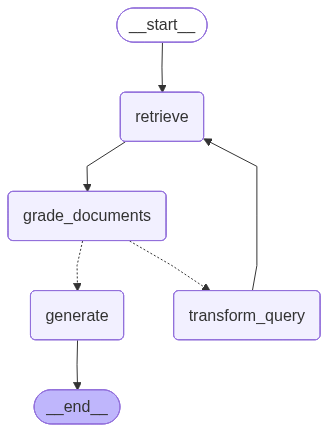

In [9]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())


## 5. Testing

### 5a. Batch invoke

In [10]:
import uuid

def run_query(question: str, thread_id: str | None = None) -> str:
    config = {'configurable': {'thread_id': thread_id or str(uuid.uuid4())}}
    result = app.invoke(
        {'question': question, 'generation': '', 'documents': [], 'retries': 0},
        config=config,
    )
    return result['generation']


test_questions = [
    'What are the pricing plans and how much does Professional cost?',
    'Is TechBase Pro GDPR compliant and how is data encrypted?',
    'How do I integrate with Slack and what SDKs are available?',
    'What is the API rate limit for Enterprise customers?',
    'What is the weather like today?',   # out-of-scope — tests graceful fallback
]

SEP = '=' * 70
print(SEP)
for q in test_questions:
    print(f'QUESTION: {q}')
    answer = run_query(q)
    print(f'\nANSWER:\n{answer}')
    print(SEP)


QUESTION: What are the pricing plans and how much does Professional cost?
  [RETRIEVE] 'What are the pricing plans and how much does Professional co'
  [RETRIEVE] 4 docs fetched.
  [GRADE] Scoring 4 docs...
    ✓ pricing
    ✗ support
    ✗ support
    ✗ integrations
  [GRADE] 1/4 relevant.
  [GENERATE] Using 1 docs.

ANSWER:
The pricing plans for TechBase Pro are as follows:

1. Starter (Free) — up to 5 users, 10 GB storage, 1,000 queries/month.
2. Professional — $49/user/month, unlimited users, 100 GB storage, unlimited queries, SSO, priority support, advanced analytics.
3. Enterprise — custom pricing, unlimited storage, dedicated infrastructure, SLA guarantees, custom integrations, on-premise deployment, 24/7 dedicated support with 1-hour response time.

The Professional plan costs $49 per user per month.
QUESTION: Is TechBase Pro GDPR compliant and how is data encrypted?
  [RETRIEVE] 'Is TechBase Pro GDPR compliant and how is data encrypted?'
  [RETRIEVE] 4 docs fetched.
  [GRADE] 

### 5b. Streaming — observe each node as it fires

In [11]:
question = 'What security certifications does TechBase Pro have?'
config = {'configurable': {'thread_id': 'stream-demo'}}

print(f'Q: {question}\n')
for step in app.stream(
    {'question': question, 'generation': '', 'documents': [], 'retries': 0},
    config=config,
    stream_mode='updates',
):
    for node_name, node_output in step.items():
        keys = list(node_output.keys())
        print(f'  [{node_name}] → {keys}')

print('\nDone.')


Q: What security certifications does TechBase Pro have?

  [RETRIEVE] 'What security certifications does TechBase Pro have?'
  [RETRIEVE] 4 docs fetched.
  [retrieve] → ['documents']
  [GRADE] Scoring 4 docs...
    ✓ security
    ✗ pricing
    ✗ product_overview
    ✗ integrations
  [GRADE] 1/4 relevant.
  [grade_documents] → ['documents']
  [GENERATE] Using 1 docs.
  [generate] → ['generation']

Done.


## 6. Interactive Query

In [12]:
question = 'How do I get started and how long does indexing take?'
config = {'configurable': {'thread_id': 'interactive-1'}}

print(f'Q: {question}\n')
result = app.invoke(
    {'question': question, 'generation': '', 'documents': [], 'retries': 0},
    config=config,
)
print(f'A: {result["generation"]}')


Q: How do I get started and how long does indexing take?

  [RETRIEVE] 'How do I get started and how long does indexing take?'
  [RETRIEVE] 4 docs fetched.
  [GRADE] Scoring 4 docs...
    ✓ getting_started
    ✗ pricing
    ✗ product_overview
    ✗ getting_started
  [GRADE] 1/4 relevant.
  [GENERATE] Using 1 docs.
A: To get started, create an account at app.techbasepro.ai, connect data sources via the integrations panel, and upload documents through the web UI, REST API, or desktop sync client. You should also configure RBAC and invite team members. The AI indexing process takes new documents within 5 minutes.
